In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import DoubleType
from pathlib import Path
import tfv.xarray
import xarray as xr  # We utilise xarray to do all the heavy lifting 
from tfv.extractor import FvExtractor
from tfv.timeseries import FvTimeSeries
from scipy.stats import gaussian_kde
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from IPython.display import Image, display
import matplotlib.ticker as mticker

In [0]:
import geopandas as gpd
import pandas as pd
import numpy as np

# Load the shapefile
shp_path = r"/Workspace/Shared/Analytics/shapefile/polyline_1.shp"
# os.environ["SHAPE_RESTORE_SHX"] = "YES"   # let GDAL rebuild .shx if possible
gdf = gpd.read_file(shp_path)
gdf = gpd.read_file(shp_path)

# Make sure the CRS is geographic (lat/lon)
if gdf.crs is not None and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Extract coordinates from any geometry type
def geometry_to_coords(geom):
    if geom is None or geom.is_empty:
        return []

    gtype = geom.geom_type
    if gtype == "Point":
        return [(geom.x, geom.y)]
    if gtype in ("LineString", "LinearRing"):
        return list(geom.coords)
    if gtype == "Polygon":
        return list(geom.exterior.coords)
    if gtype.startswith("Multi") or gtype == "GeometryCollection":
        coords = []
        for part in geom.geoms:
            coords.extend(geometry_to_coords(part))
        return coords

    return []

coords = []
for geom in gdf.geometry:
    coords.extend(geometry_to_coords(geom))

polyline = np.array(coords)

# Optional dataframe with lon/lat columns
df = pd.DataFrame(polyline, columns=["longitude", "latitude"])

In [0]:
# Calculate chainage (distance from north) for the four stations along the polyline
station_points = {
    'MR': (115.72983, -32.066497),
    'OA9S': (115.731672, -32.104168),
    'OA1-DEP': (115.726209, -32.124373),
    '6147030': (115.70274, -32.156587),
    '6142974': (115.719833, -32.197565),
    'LP': (115.746666, -32.226664),
    'SF11': (115.721449, -32.242053),
    '6142983': (115.712531, -32.248232),
    'SC': (115.684285, -32.254165),
    'SC2': (115.686273, -32.298863), 
}

# Convert lon/lat to local meters using a latitude-based scale factor
lat_ref = float(np.mean(polyline[:, 1]))
meters_per_deg_lat = 111320.0
meters_per_deg_lon = 111320.0 * np.cos(np.deg2rad(lat_ref))

# Cumulative chainage along the polyline (from south to north)
dx = np.diff(polyline[:, 0]) * meters_per_deg_lon
dy = np.diff(polyline[:, 1]) * meters_per_deg_lat
segment_lengths = np.sqrt(dx**2 + dy**2)
chainage = np.concatenate(([0.0], np.cumsum(segment_lengths)))

# Reverse chainage to calculate from north
chainage_from_north = chainage[-1] - chainage

# Find the nearest polyline location for each station
station_chainage = {}
rows = []
for name, (lon, lat) in station_points.items():
    d2 = ((polyline[:, 0] - lon) * meters_per_deg_lon) ** 2 + ((polyline[:, 1] - lat) * meters_per_deg_lat) ** 2
    closest_idx = int(np.argmin(d2))
    ch = float(chainage_from_north[closest_idx])
    station_chainage[name] = ch
    rows.append({
        'Name': name,
        'Longitude': lon,
        'Latitude': lat,
        'Nearest polyline idx': closest_idx,
        'Chainage from North (m)': ch,
        'Chainage from North (km)': ch / 1000.0,
    })

# Sort by station order as defined in station_points
station_order = list(station_points.keys())
station_chainage_df = pd.DataFrame(rows)
station_chainage_df['Station Order'] = station_chainage_df['Name'].apply(lambda x: station_order.index(x))
station_chainage_df = station_chainage_df.sort_values('Station Order').reset_index(drop=True)
display(station_chainage_df)

,Name,Longitude,Latitude,Nearest polyline idx,Chainage from North (m),Chainage from North (km),Station Order
0,MR,115.729830,-32.066497,51,520.488552,0.520489,0
1,OA9S,115.731672,-32.104168,45,4738.814701,4.738815,1
2,OA1-DEP,115.726209,-32.124373,42,7152.124693,7.152125,2
3,6147030,115.702740,-32.156587,38,11378.033818,11.378034,3
4,6142974,115.719833,-32.197565,33,16548.714669,16.548715,4
5,LP,115.746666,-32.226664,25,20892.516084,20.892516,5
6,SF11,115.721449,-32.242053,19,23874.342667,23.874343,6
7,6142983,115.712531,-32.248232,14,24993.896403,24.993896,7
8,SC,115.684285,-32.254165,8,27747.695356,27.747695,8
9,SC2,115.686273,-32.298863,1,33219.559097,33.219559,9


In [0]:
from pathlib import Path 
model_folder = Path(r'/Volumes/wesport-shared-catalog/shared-datalake/csiem-model/wwmsp/V1.7.0/2023A-20251124131331/results/')
model_file = 'csiem_A002_20221101_20240401_WQ.nc'
ds=xr.open_dataset(model_folder / model_file)
fv=ds.tfv
fv

<xarray.Dataset> Size: 86GB
Dimensions:      (Time: 12361, NumLayerFaces3D: 252490, NumCells2D: 11694,
                  NumCells3D: 240796)
Coordinates:
  * Time         (Time) datetime64[ns] 99kB 2022-11-02 ... 2024-03-31
Dimensions without coordinates: NumLayerFaces3D, NumCells2D, NumCells3D
Data variables:
    ResTime      (Time) datetime64[ns] 99kB 2022-11-02 ... 2024-03-31
    layerface_Z  (Time, NumLayerFaces3D) float32 12GB ...
    stat         (Time, NumCells2D) int32 578MB ...
    H            (Time, NumCells2D) float32 578MB ...
    D            (Time, NumCells2D) float32 578MB ...
    V_x          (Time, NumCells3D) float32 12GB ...
    V_y          (Time, NumCells3D) float32 12GB ...
    W            (Time, NumCells3D) float32 12GB ...
    SAL          (Time, NumCells3D) float32 12GB ...
    TEMP         (Time, NumCells3D) float32 12GB ...
    RHOW         (Time, NumCells3D) float32 12GB ...
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLOWFV output
    spherical:  true
    Dry depth:  0.01

<xarray.Dataset> Size: 86GB
Dimensions:      (Time: 12361, NumLayerFaces3D: 252490, NumCells2D: 11694,
                  NumCells3D: 240796)
Coordinates:
  * Time         (Time) datetime64[ns] 99kB 2022-11-02 ... 2024-03-31
Dimensions without coordinates: NumLayerFaces3D, NumCells2D, NumCells3D
Data variables:
    ResTime      (Time) datetime64[ns] 99kB 2022-11-02 ... 2024-03-31
    layerface_Z  (Time, NumLayerFaces3D) float32 12GB ...
    stat         (Time, NumCells2D) int32 578MB ...
    H            (Time, NumCells2D) float32 578MB ...
    D            (Time, NumCells2D) float32 578MB ...
    V_x          (Time, NumCells3D) float32 12GB ...
    V_y          (Time, NumCells3D) float32 12GB ...
    W            (Time, NumCells3D) float32 12GB ...
    SAL          (Time, NumCells3D) float32 12GB ...
    TEMP         (Time, NumCells3D) float32 12GB ...
    RHOW         (Time, NumCells3D) float32 12GB ...
Attributes:
    Origin:     Created by TUFLOWFV
    Type:       Cell-centred TUFLO

In [0]:
df = spark.read.parquet("/Volumes/wesport-shared-catalog/shared-datalake/csiem-data/v1.7.0/data-warehouse/parquet/WAMSI-WWMSP3-CTD_DWER-CSMWQ.parquet")

In [0]:
site_descriptions = ["SC2", "SC", "6142983", "SF11", "LP", "6142974", "6147030", "OA1-DEP", "OA9S", "MR"]

filtered_df = df.filter(
    ((df.Agency.isin(["DWER-CSMWQ", "WAMSI-WWMSP3-CTD"])) &
     (df.Site_Description.isin(site_descriptions)) &
    (df.Date >= "2022-01-01") &
    (df.Date <= "2023-06-30")
))
filtered_df = filtered_df.filter(filtered_df.Variable.isin(["Temperature (C)", "Salinity (psu)"]))
selected_df = filtered_df.select("Date", "Depth", "Data", "Agency", "Lat", "Long", 'Site_Description')
display(selected_df)

DataFrame[Date: timestamp_ntz, Depth: double, Data: double, Agency: string, Lat: double, Long: double, Site_Description: string]

In [0]:
import numpy as np
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import DoubleType

# Define the UNESCO EOS-80 density function as a Pandas UDF
@pandas_udf(DoubleType())
def unesco_eos80_density_udf(S, T, p):
    S = S.astype(float)
    T = T.astype(float)
    p = p.astype(float)
    p_bar = p * 0.1
    T2, T3, T4, T5 = T*T, T*T*T, T*T*T*T, T*T*T*T*T
    S_sqrt, S1p5, S2 = np.sqrt(S), S*np.sqrt(S), S*S
    a0, a1, a2, a3, a4, a5 = 999.842594, 6.793952e-2, -9.095290e-3, 1.001685e-4, -1.120083e-6, 6.536332e-9
    rho_w = a0 + a1*T + a2*T2 + a3*T3 + a4*T4 + a5*T5
    b0, b1, b2, b3, b4 = 8.24493e-1, -4.0899e-3, 7.6438e-5, -8.2467e-7, 5.3875e-9
    c0, c1, c2 = -5.72466e-3, 1.0227e-4, -1.6546e-6
    d0 = 4.8314e-4
    rho_ST0 = rho_w + (b0 + b1*T + b2*T2 + b3*T3 + b4*T4)*S + (c0 + c1*T + c2*T2)*S1p5 + d0*S2
    e0, e1, e2, e3, e4 = 19652.21, 148.4206, -2.327105, 1.360477e-2, -5.155288e-5
    K_w = e0 + e1*T + e2*T2 + e3*T3 + e4*T4
    f0, f1, f2, f3 = 54.6746, -0.603459, 1.09987e-2, -6.1670e-5
    g0, g1, g2 = 7.944e-2, 1.6483e-2, -5.3009e-4
    K_ST0 = K_w + (f0 + f1*T + f2*T2 + f3*T3)*S + (g0 + g1*T + g2*T2)*S1p5
    h0, h1, h2, h3 = 3.239908, 1.43713e-3, 1.16092e-4, -5.77905e-7
    A_w = h0 + h1*T + h2*T2 + h3*T3
    i0, i1, i2 = 2.2838e-3, -1.0981e-5, -1.6078e-6
    B_w = i0 + i1*T + i2*T2
    j0 = 1.91075e-4
    K_w_p = A_w*p_bar + B_w*p_bar**2 + j0*p_bar**3
    m0, m1, m2 = 8.50935e-5, -6.12293e-6, 5.2787e-8
    n0, n1, n2 = -9.9348e-7, 2.0816e-8, 9.1697e-10
    K_STp = ((m0 + m1*T + m2*T2)*S + (n0 + n1*T + n2*T2)*S1p5)*p_bar
    K = K_ST0 + K_w_p + K_STp
    rho = rho_ST0 / (1.0 - p_bar / K)
    return rho

# Pivot temperature and salinity into columns
pivoted_df = filtered_df.groupBy("Date", "Depth", "Site_Description") \
    .pivot("Variable", ["Temperature (C)", "Salinity (psu)"]) \
    .agg({"Data": "first"})

# Drop rows with nulls in required columns to avoid UDF errors
pivoted_df = pivoted_df.dropna(subset=["Temperature (C)", "Salinity (psu)", "Depth"])

# Add Density column using the UDF, assuming Depth is in meters (pressure in dbar ~= depth in m)
pivoted_df = pivoted_df.withColumn(
    "Density",
    unesco_eos80_density_udf(
        pivoted_df["Salinity (psu)"],
        pivoted_df["Temperature (C)"],
        pivoted_df["Depth"]
    )
)

display(pivoted_df)

DataFrame[Date: timestamp_ntz, Depth: double, Site_Description: string, Temperature (C): double, Salinity (psu): double, Density: double]

In [0]:
df=pivoted_df.toPandas()
dates = sorted(df['Date'].dt.date.unique())

print(f"Total number of dates: {len(dates)}")
print(f"\nAll dates with sites covered:")
for i, date in enumerate(dates, 1):
    date_data = df[df['Date'].dt.date == date]
    count = len(date_data)
    sites = sorted(date_data['Site_Description'].unique())
    num_sites = len(sites)
    print(f"  {i}. {date} - {count} records from {num_sites} sites: {', '.join(sites)}")

Total number of dates: 19

All dates with sites covered:
  1. 2023-01-11 - 587 records from 3 sites: MR, OA1-DEP, OA9S
  2. 2023-01-12 - 1139 records from 4 sites: LP, SC, SC2, SF11
  3. 2023-01-24 - 230 records from 1 sites: 6147030
  4. 2023-01-25 - 419 records from 2 sites: 6142974, 6142983
  5. 2023-02-03 - 896 records from 7 sites: LP, MR, OA1-DEP, OA9S, SC, SC2, SF11
  6. 2023-02-15 - 312 records from 2 sites: 6142974, 6142983
  7. 2023-02-16 - 188 records from 1 sites: 6147030
  8. 2023-03-08 - 271 records from 1 sites: SF11
  9. 2023-03-21 - 94 records from 1 sites: 6147030
  10. 2023-03-22 - 134 records from 2 sites: 6142974, 6142983
  11. 2023-04-18 - 574 records from 7 sites: LP, MR, OA1-DEP, OA9S, SC, SC2, SF11
  12. 2023-04-19 - 80 records from 1 sites: 6142983
  13. 2023-04-20 - 261 records from 2 sites: 6142974, 6147030
  14. 2023-05-02 - 200 records from 2 sites: 6142974, 6142983
  15. 2023-05-03 - 566 records from 5 sites: 6147030, LP, SC, SC2, SF11
  16. 2023-05-04 - 

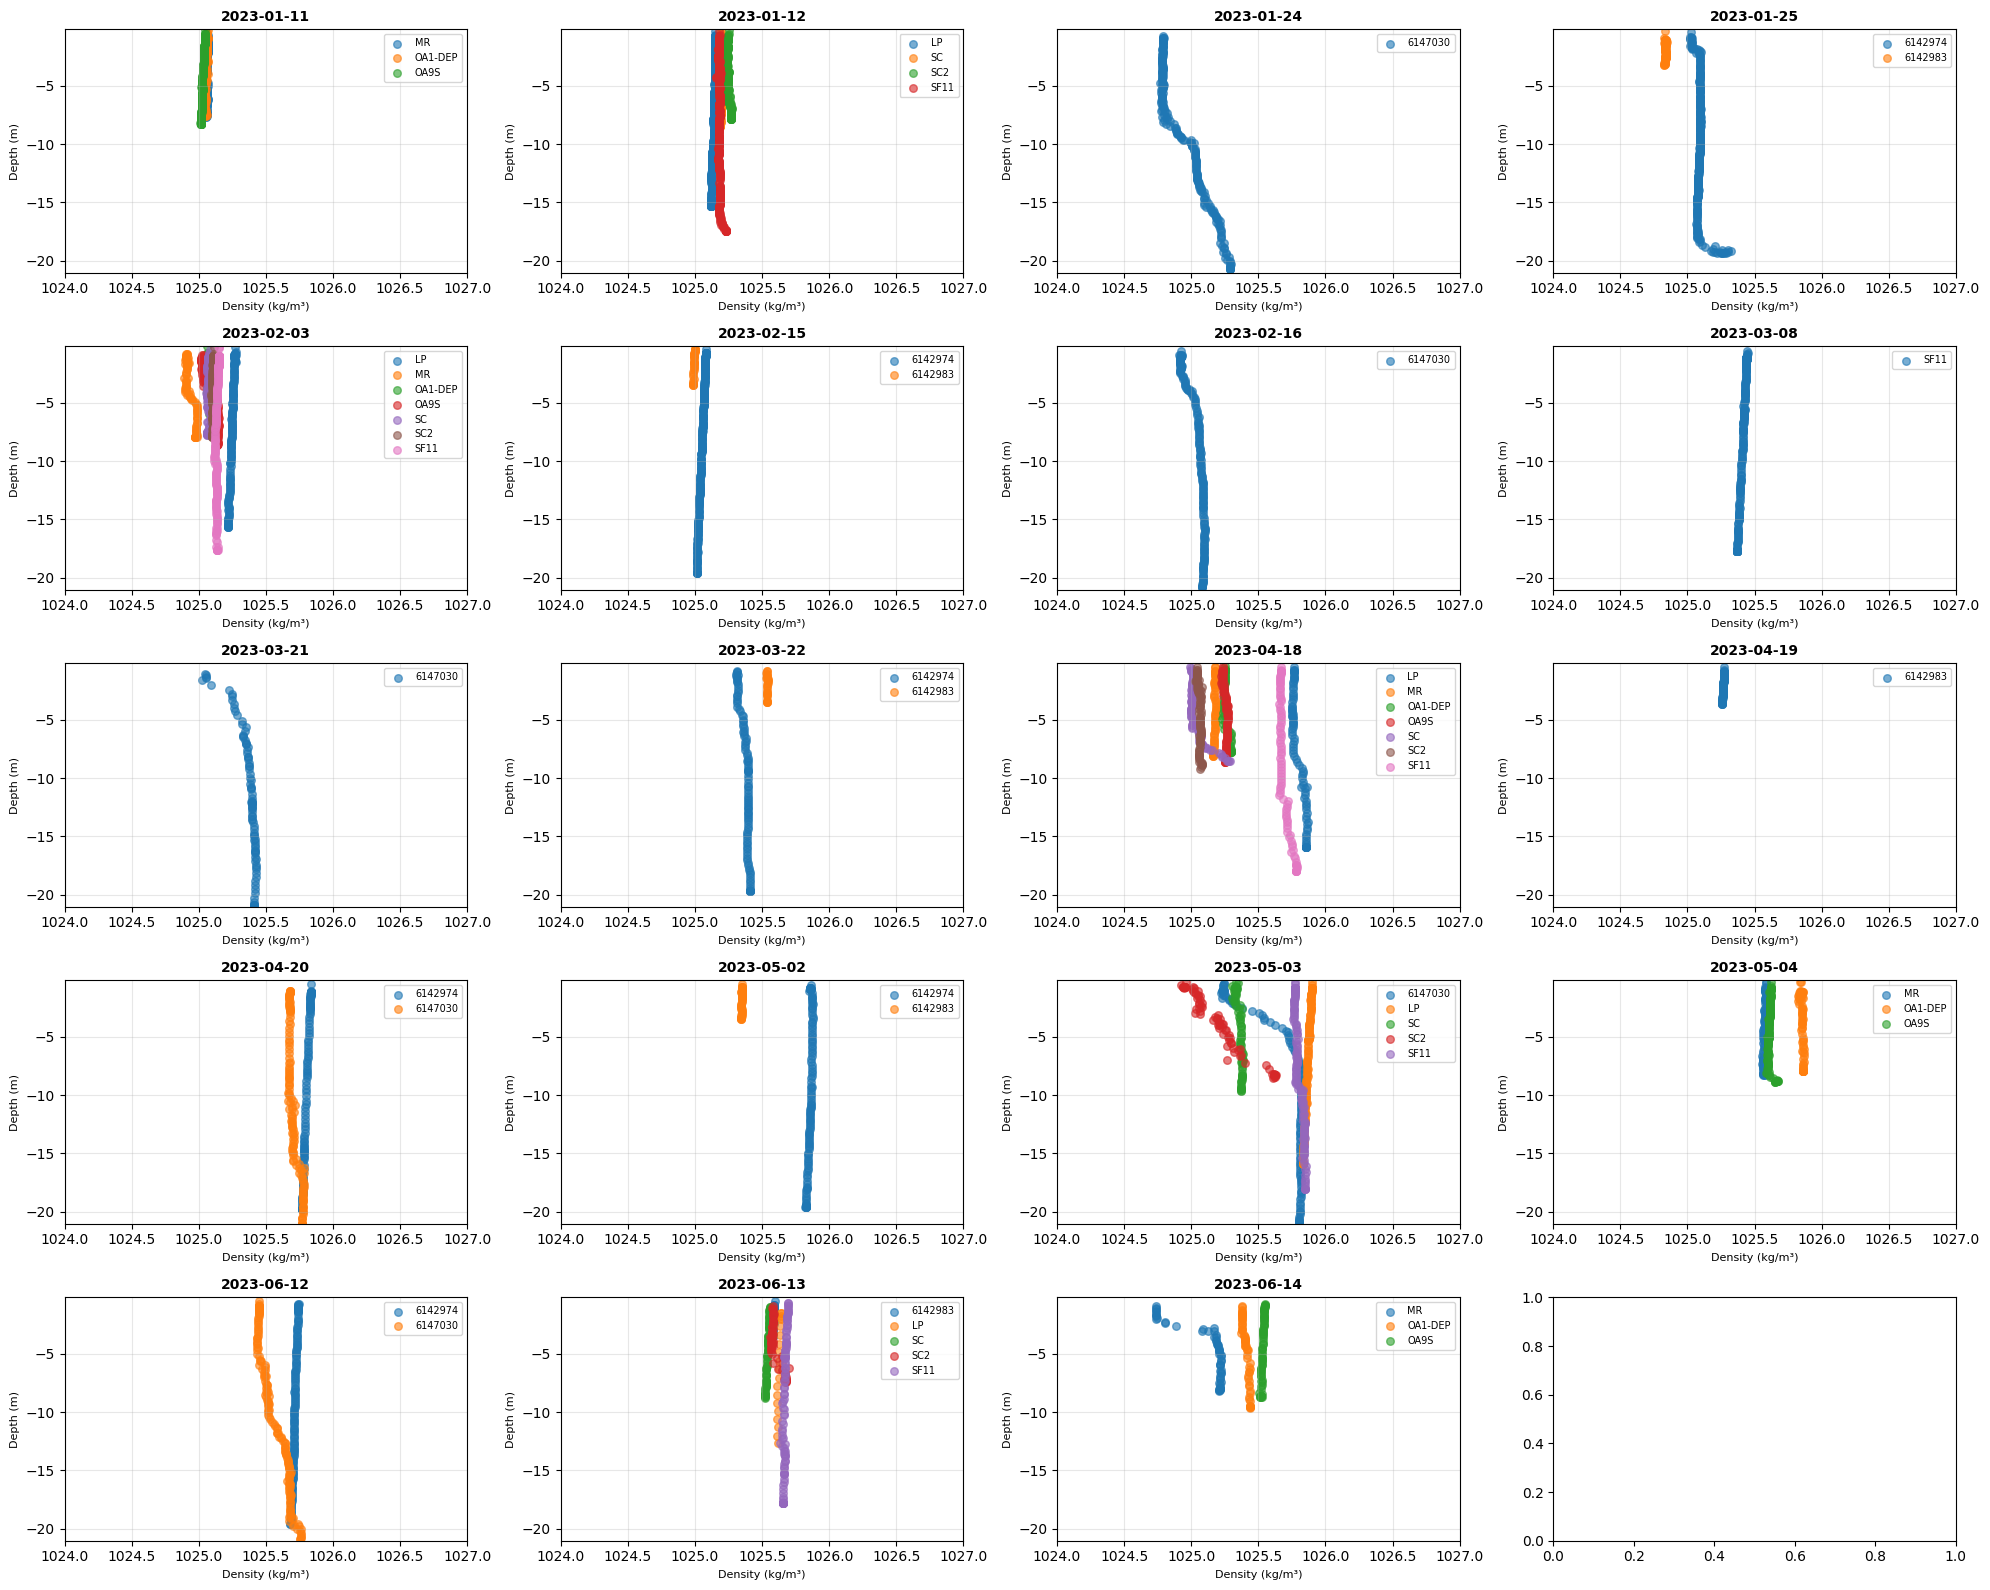

In [0]:
df=pivoted_df.toPandas()
import pandas as pd
import matplotlib.pyplot as plt
sites = sorted(df['Site_Description'].unique())
dates = sorted(df['Date'].dt.date.unique())

# Create 16 subplots (one per date)
fig, axes = plt.subplots(5, 4, figsize=(20, 16))
axes = axes.flatten()

y_min, y_max = df['Depth'].min(), df['Depth'].max()

for idx, date in enumerate(dates[:20]):
    ax = axes[idx]
    date_data = df[df['Date'].dt.date == date]
    
    for site in sites:
        site_date_data = date_data[date_data['Site_Description'] == site]
        if len(site_date_data) > 0:
            ax.scatter(site_date_data['Density'], site_date_data['Depth'], 
                      label=site, alpha=0.6, s=30)
    
    ax.set_title(f"{date}", fontweight='bold', fontsize=10)
    ax.set_xlabel('Density (kg/m³)', fontsize=8)
    ax.set_ylabel('Depth (m)', fontsize=8)
    ax.set_xlim(1024, 1027)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

# fig.suptitle('Field Data (Density): Each Panel = One Date (16 dates total)', 
#              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [0]:
polyline = polyline[::-1].copy()

2023-01: Mean observed density = 1025.101 kg/m³
Plotting curtain transect for 2023-01...
Saved: transect_profiles_curtain_2023-01.png



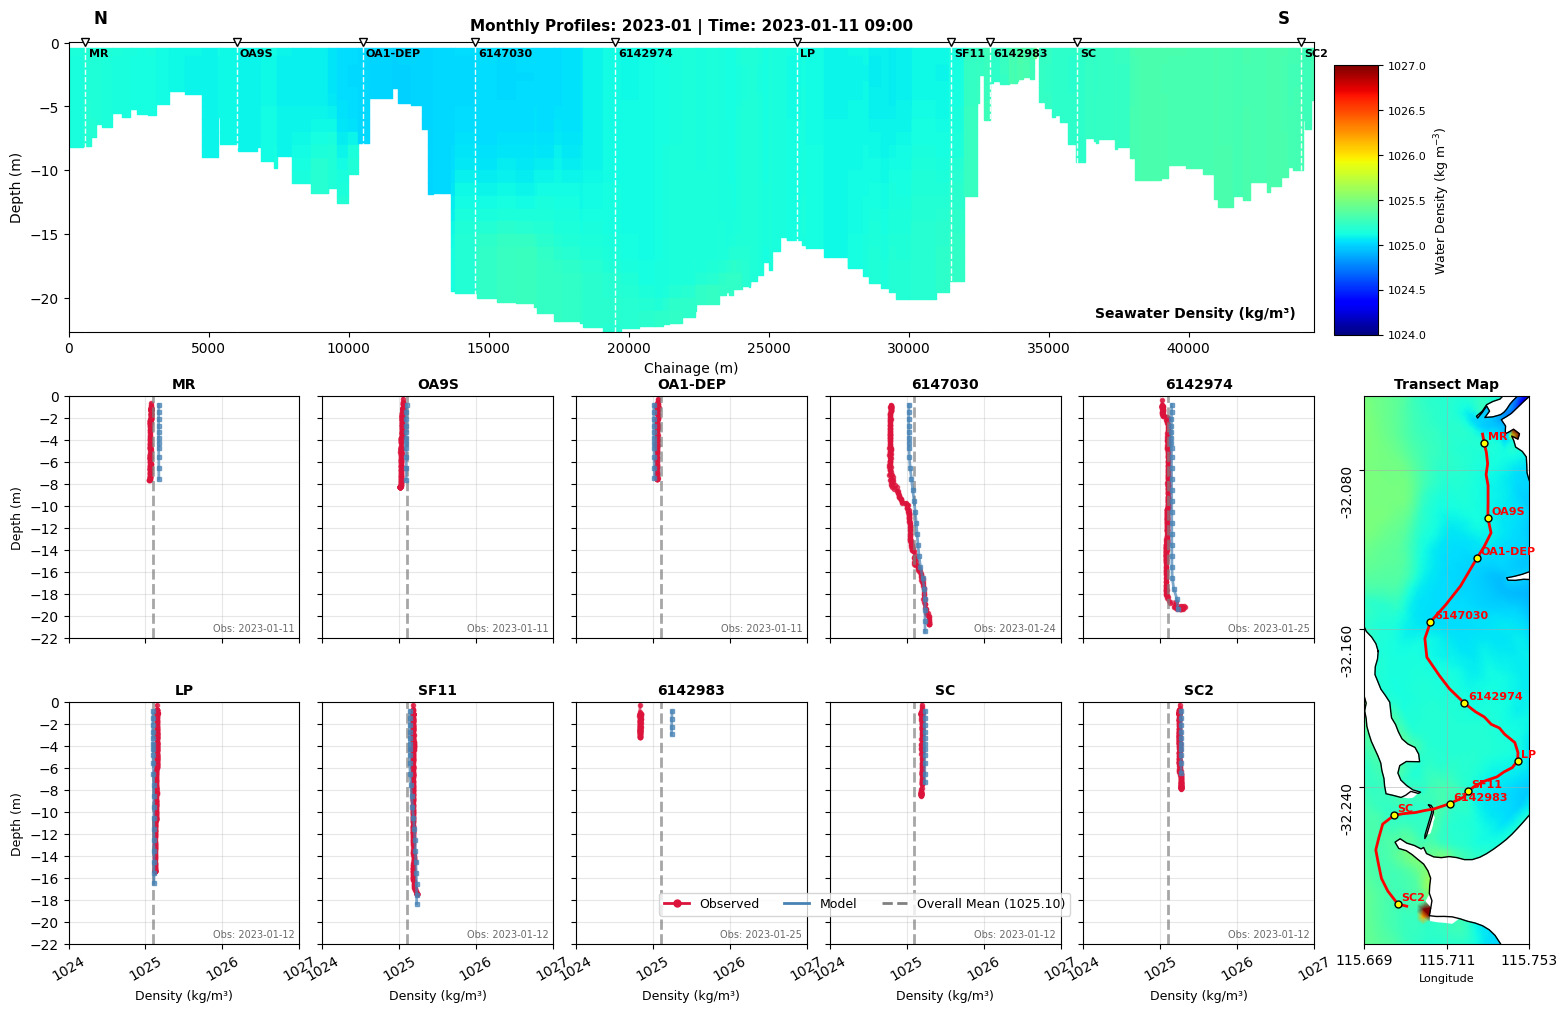

2023-02: Mean observed density = 1025.087 kg/m³
Plotting curtain transect for 2023-02...
Saved: transect_profiles_curtain_2023-02.png



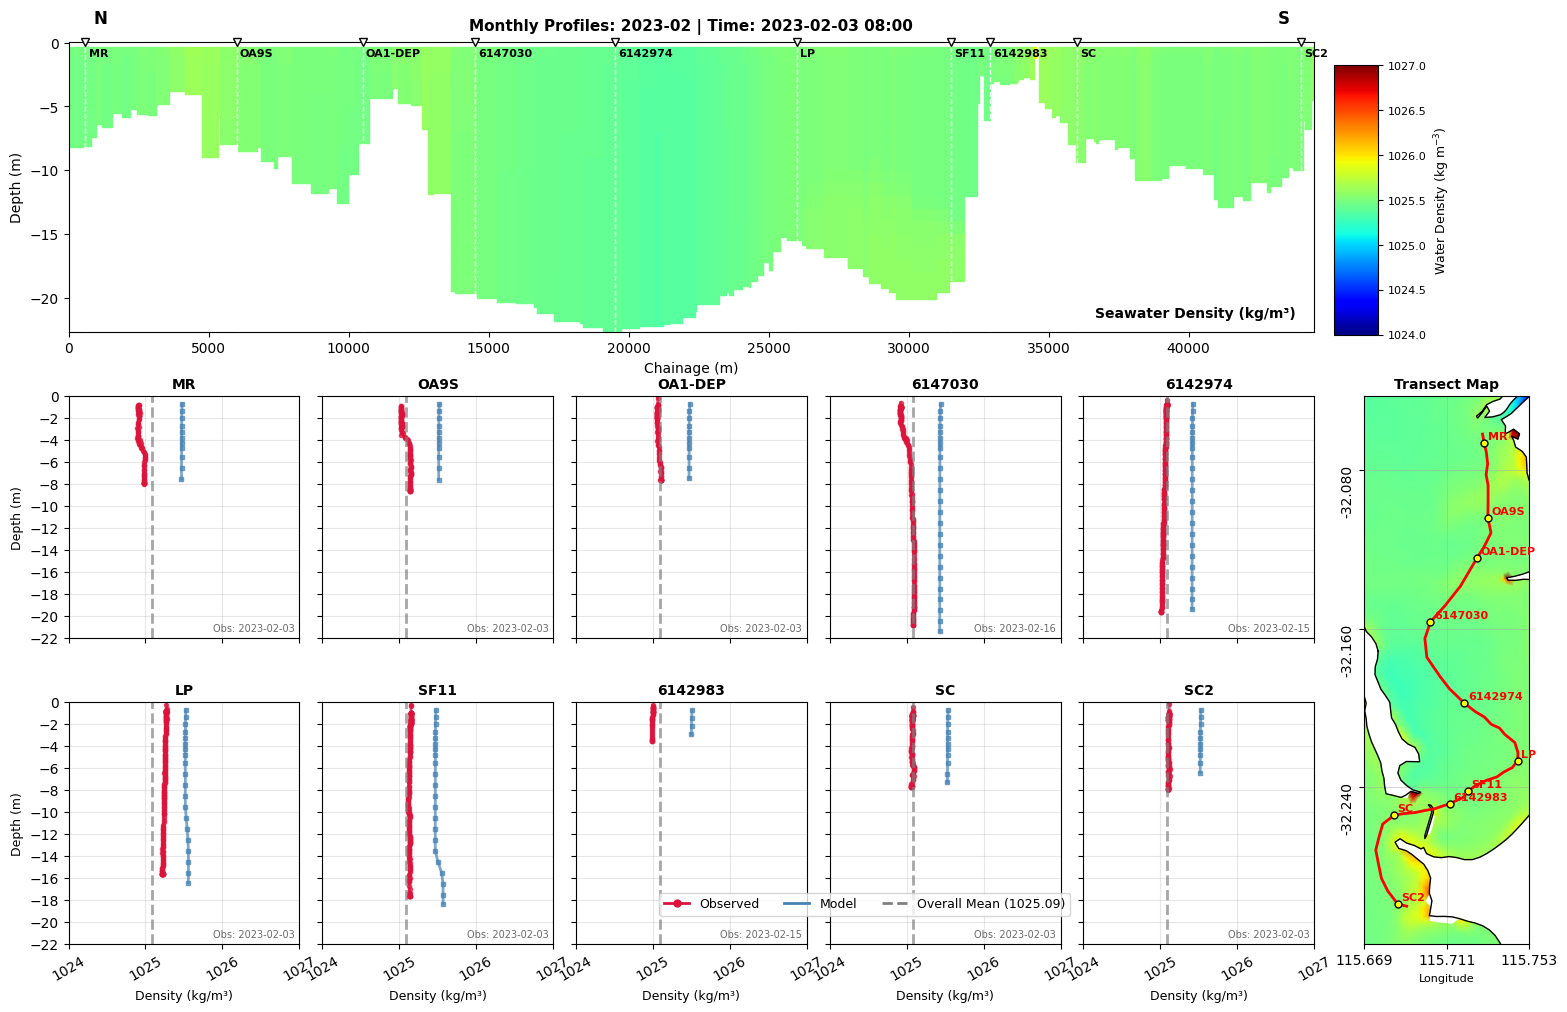

2023-03: Mean observed density = 1025.399 kg/m³
Plotting curtain transect for 2023-03...
Saved: transect_profiles_curtain_2023-03.png



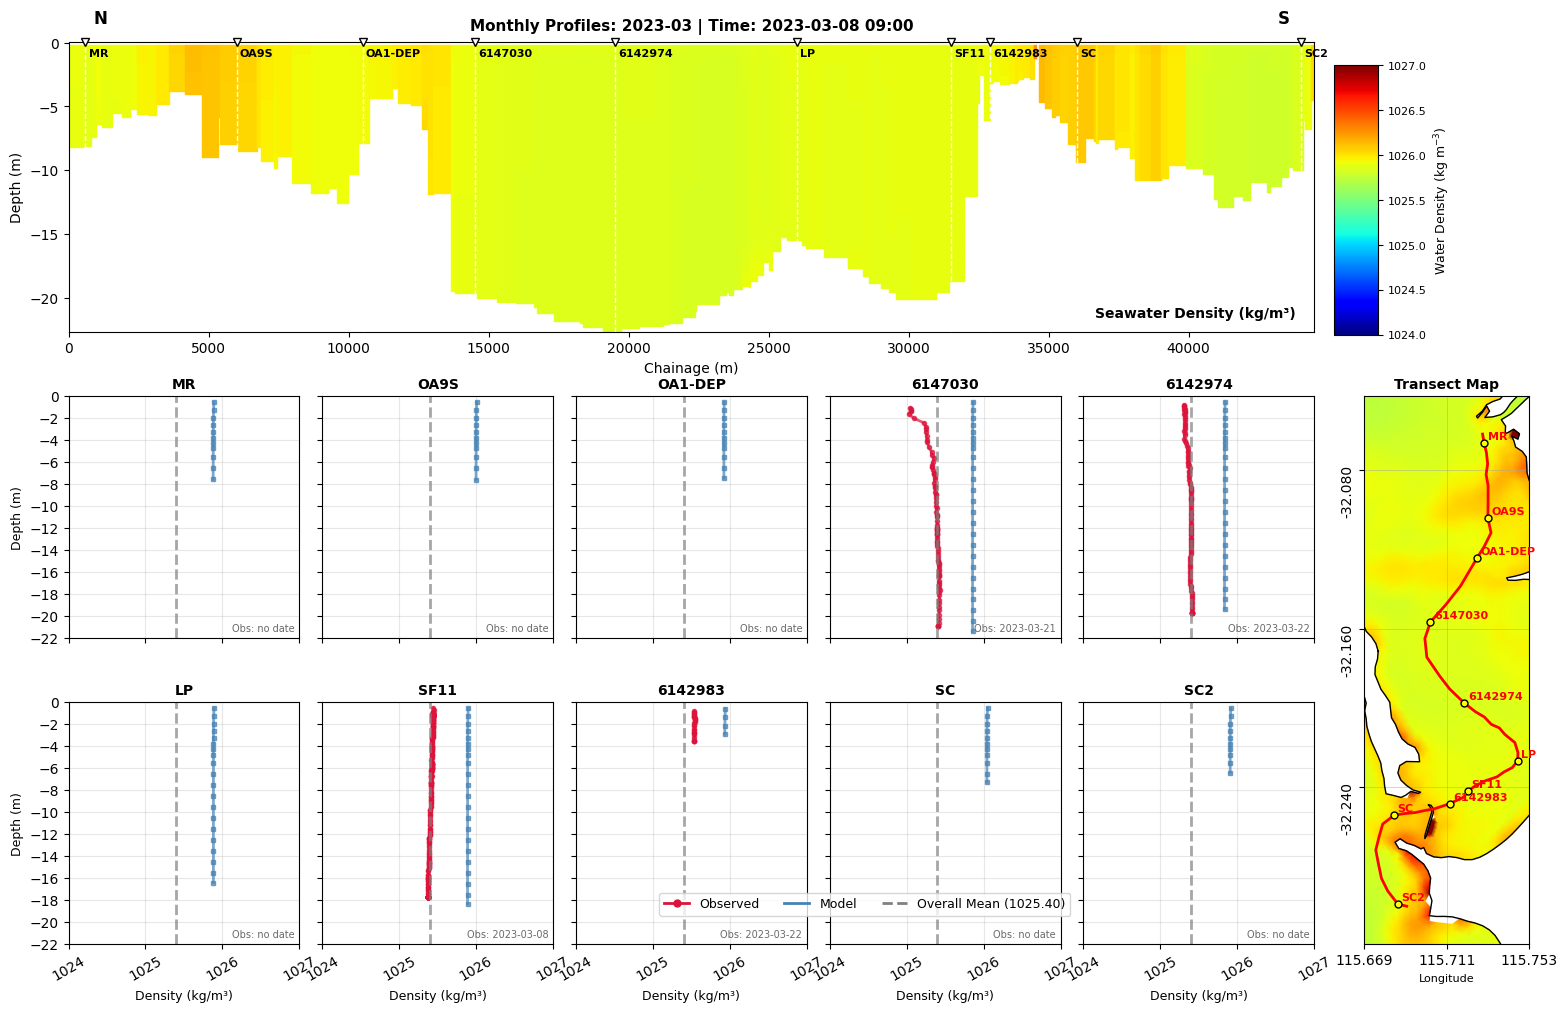

2023-04: Mean observed density = 1025.453 kg/m³
Plotting curtain transect for 2023-04...
Saved: transect_profiles_curtain_2023-04.png



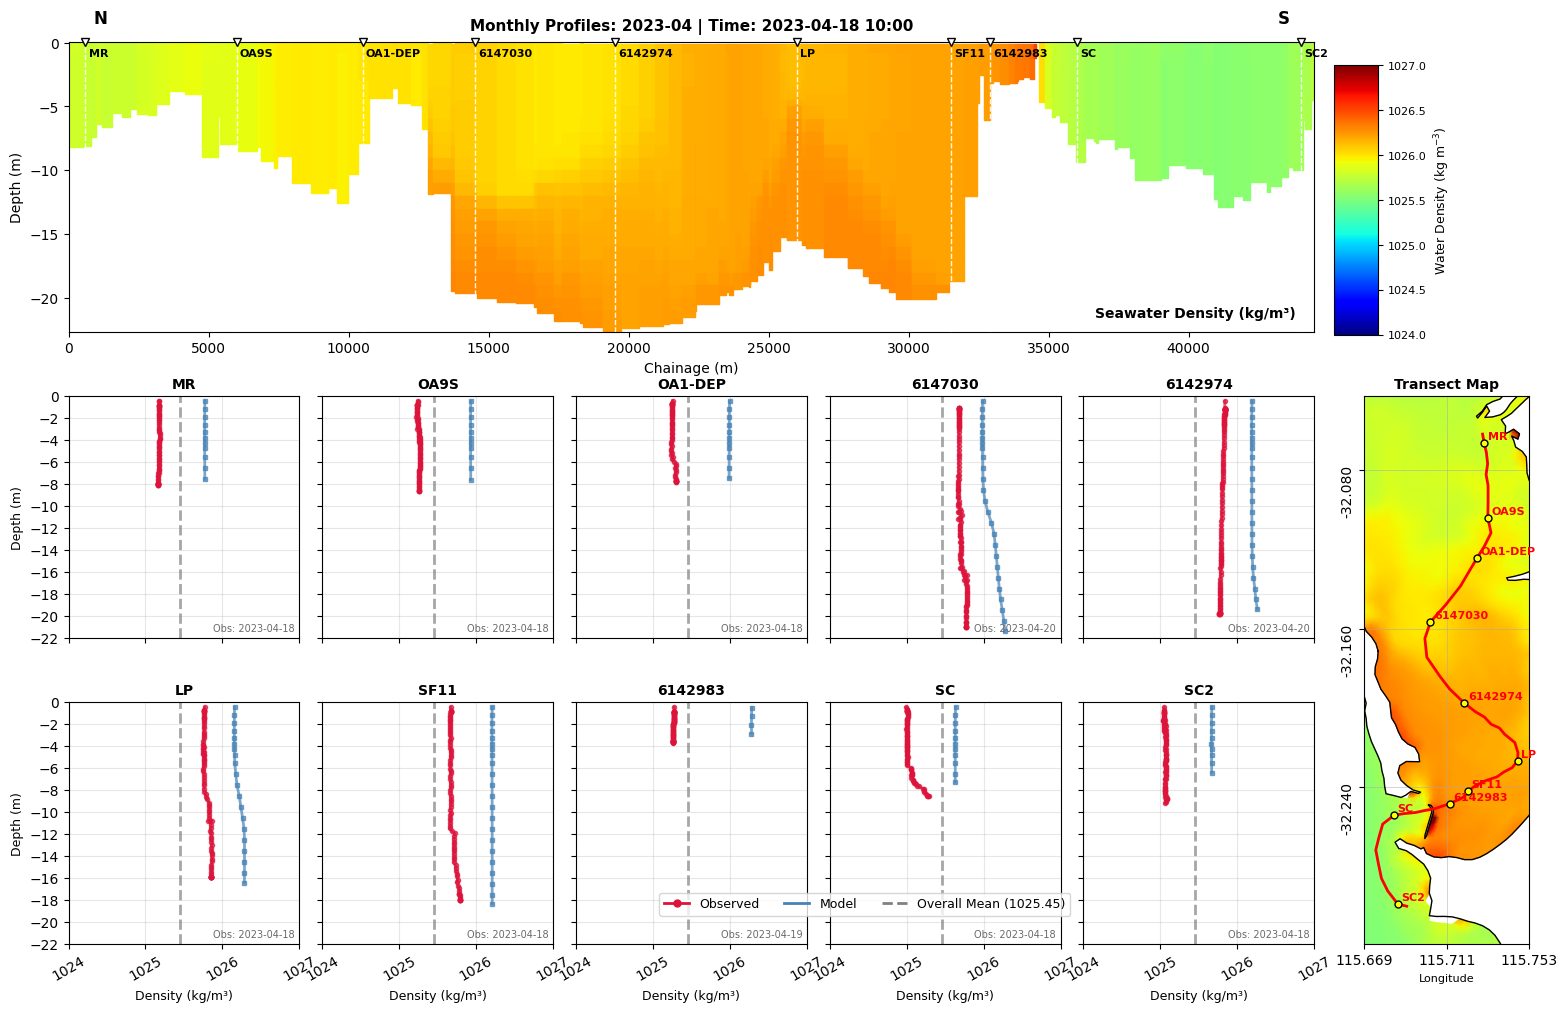

2023-05: Mean observed density = 1025.651 kg/m³
Plotting curtain transect for 2023-05...
Saved: transect_profiles_curtain_2023-05.png



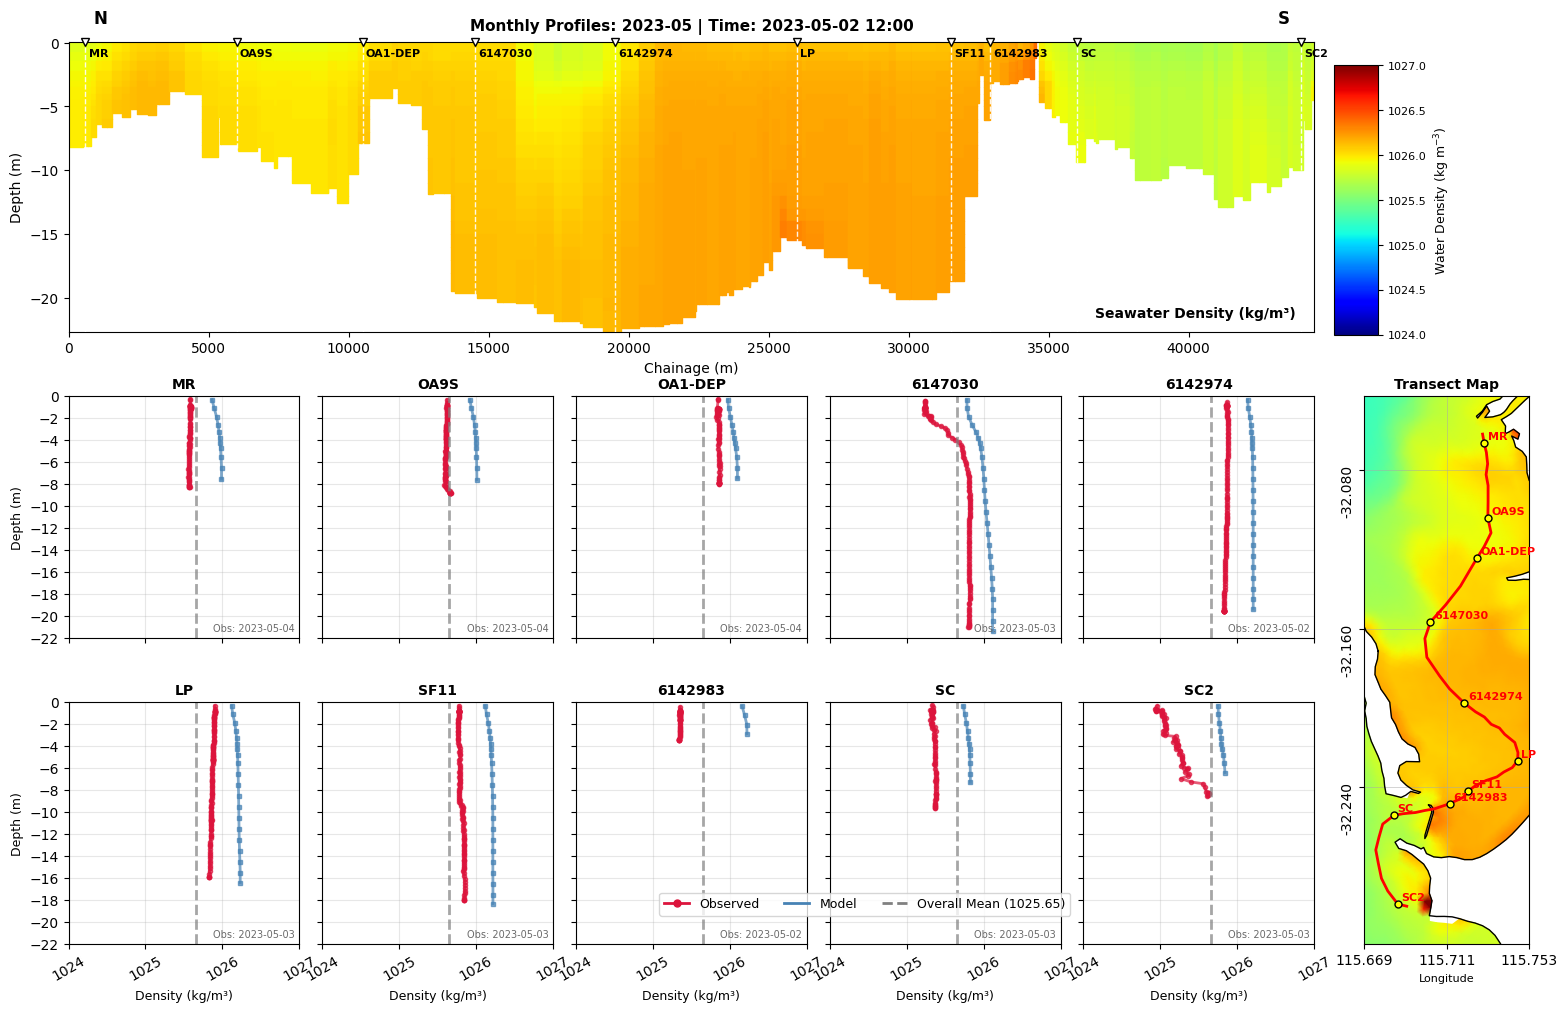

2023-06: Mean observed density = 1025.558 kg/m³
Plotting curtain transect for 2023-06...
Saved: transect_profiles_curtain_2023-06.png



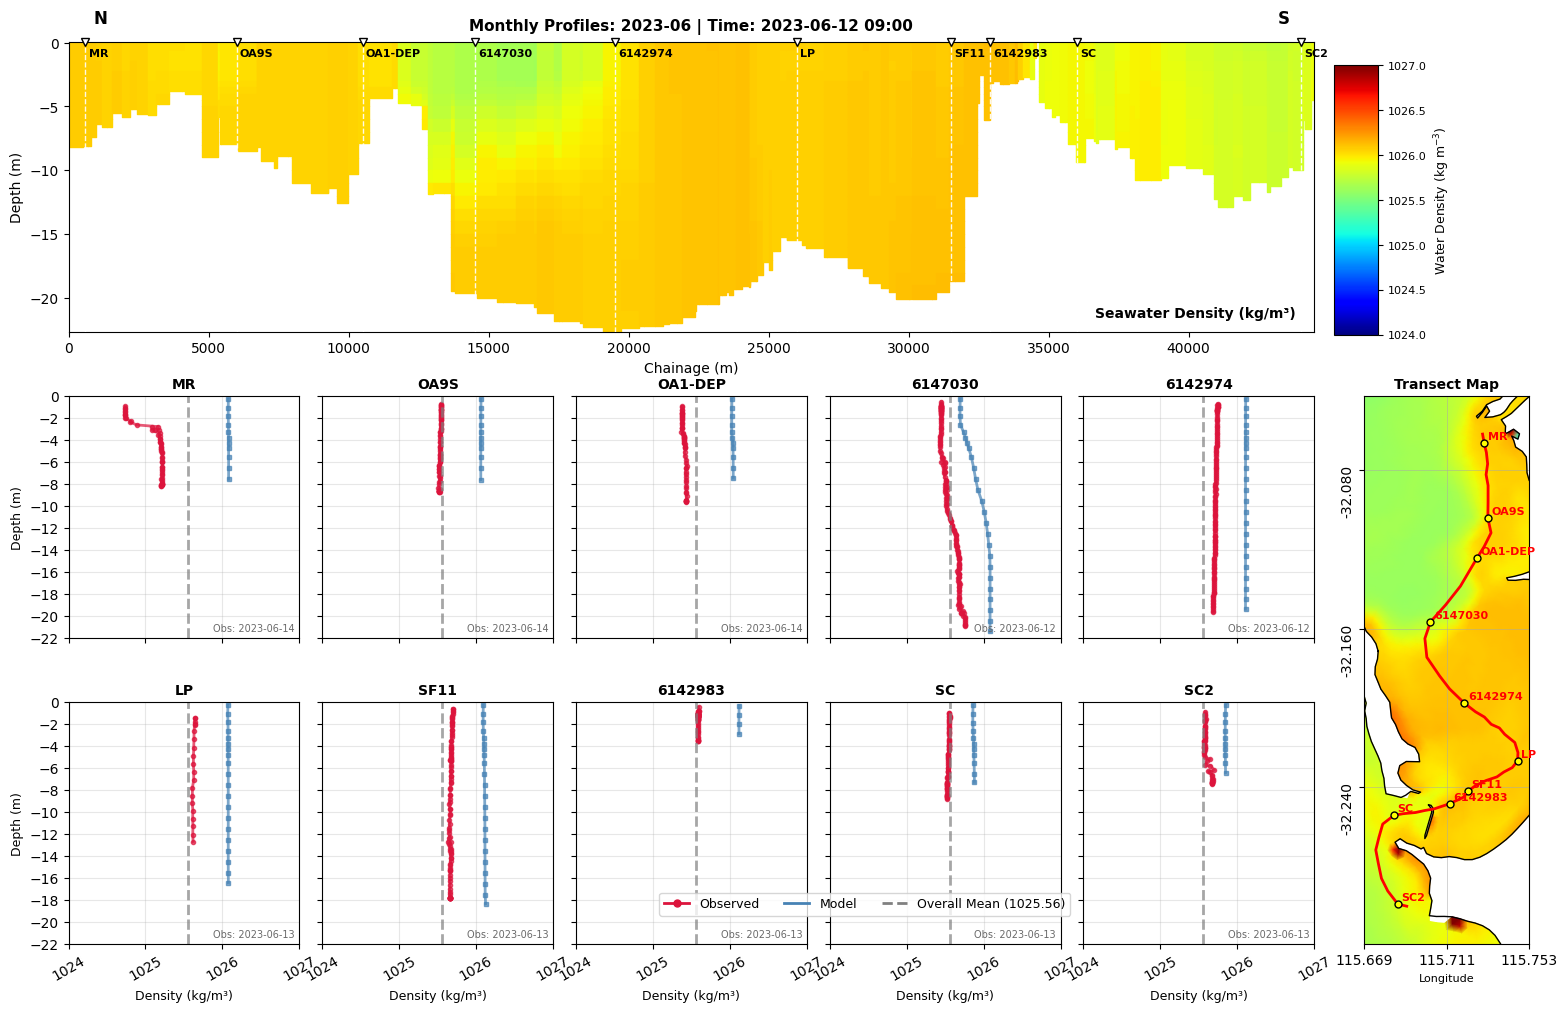

Done! All 6 monthly plots with curtain transect + profiles saved.


In [0]:

sites = list(station_points.keys())
manual_station_chainage = {
    'MR': 600,
    'OA9S': 6000,
    'OA1-DEP': 10500,
    '6147030': 14500,
    '6142974': 19500,
    'LP': 26000,
    'SF11': 31500,
    '6142983': 32900,
    'SC': 36000,
    'SC2': 44000,
}
rhow_spec = dict(cmap='jet', clim=(1024, 1027), shading='interp', colorbar=False, boundary=True)
df_obs= df

# Get unique months
df_obs['YearMonth'] = df_obs['Date'].dt.to_period('M')
months = sorted(df_obs['YearMonth'].unique())
representative_dates = []
for month in months:
    month_data = df_obs[df_obs['YearMonth'] == month]
    first_date = month_data['Date'].min()
    representative_dates.append(pd.to_datetime(first_date).floor('h'))

# Helper functions
def _to_negative_down(depth_vals):
    finite_depth = depth_vals[np.isfinite(depth_vals)]
    if finite_depth.size and np.nanmedian(finite_depth) > 0:
        return -depth_vals
    return depth_vals

def _format_site_dates(dt_series):
    dts = pd.to_datetime(dt_series.dropna()).dt.normalize().drop_duplicates().sort_values()
    if len(dts) == 0:
        return 'Obs: no date'
    if len(dts) == 1:
        return f"Obs: {dts.iloc[0].strftime('%Y-%m-%d')}"
    if len(dts) <= 3:
        joined = ', '.join(d.strftime('%m-%d') for d in dts)
        return f"Obs: {joined}"
    return f"Obs: {dts.iloc[0].strftime('%m-%d')} to {dts.iloc[-1].strftime('%m-%d')}"

from matplotlib import cm, colors

# Create one figure for each month
y_min, y_max = -22, 0

for month_idx, (month, model_date) in enumerate(zip(months, representative_dates)):
    fig = plt.figure(figsize=(16, 11), constrained_layout=False)
    gs = fig.add_gridspec(3, 6, width_ratios=[1, 1, 1, 1, 1, 0.95], 
                          height_ratios=[1.2, 1, 1], hspace=0.25, wspace=0.10)
    
    # Transect panel (top, spans first 5 columns to align with profile grid)
    ax_transect = fig.add_subplot(gs[0, :5])
    
    # Profile panels (remaining 2 rows x 5 columns)
    profile_axes = []
    for r in range(1, 3):
        for c in range(5):
            if not profile_axes:
                axp = fig.add_subplot(gs[r, c])
            else:
                axp = fig.add_subplot(gs[r, c], sharey=profile_axes[0])
            profile_axes.append(axp)
    
    # Colorbar panel in top-right (row 1, col 6), using a slim inset axis
    ax_cbar_slot = fig.add_subplot(gs[0, 5])
    cbar_slot_pos = ax_cbar_slot.get_position()
    ax_cbar_slot.remove()
    cbar_w = cbar_slot_pos.width * 0.24
    cbar_h = cbar_slot_pos.height * 0.99
    cbar_x = cbar_slot_pos.x0 + (cbar_slot_pos.width - cbar_w) * 0.75
    cbar_y = cbar_slot_pos.y0 + (cbar_slot_pos.height - cbar_h) * 0.5
    ax_cbar = fig.add_axes([cbar_x, cbar_y, cbar_w, cbar_h])
    
    # Map panel in lower-right (merged: rows 2-3, col 6)
    ax_map = fig.add_subplot(gs[1:, 5])
    
    month_data = df_obs[df_obs['YearMonth'] == month]
    
    # ========== CALCULATE OVERALL MEAN DENSITY (ALL 10 PROFILES) ==========
    overall_mean_density = None
    if not month_data.empty:
        overall_mean_density = month_data['Density'].mean()
        print(f"{month}: Mean observed density = {overall_mean_density:.3f} kg/m³")
    
    # ========== EXTRACT AND PLOT MODEL TRANSECT USING fv.plot_curtain ==========
    print(f"Plotting curtain transect for {month}...")
    
    try:
        # Curtain plot spanning right area
        cs = fv.plot_curtain(
            polyline,
            "RHOW",
            time=model_date,
            ax=ax_transect,
            ec="face",
            clim=(1024, 1027),
            colorbar=False,
            cmap="jet",
        )
        try:
            cbar = fig.colorbar(cs, cax=ax_cbar, orientation='vertical')
        except Exception:
            sm = cm.ScalarMappable(norm=colors.Normalize(vmin=1024, vmax=1027), cmap='jet')
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=ax_cbar, orientation='vertical')
        cbar.set_label('Water Density (kg m$^{-3}$)', fontsize=9)
        cbar.ax.tick_params(labelsize=8)
        
        # Add station markers on curtain plot using chainage
        y_top = max(ax_transect.get_ylim())
        for name, (lon, lat) in station_points.items():
            x_ch = manual_station_chainage.get(name)
            if x_ch is None:
                continue
            ax_transect.axvline(x=x_ch, color='white', linestyle='--', linewidth=1.0, alpha=0.9, zorder=8)
            ax_transect.plot(x_ch, y_top, marker='v', markersize=6, markerfacecolor='white', 
                           markeredgecolor='black', clip_on=False, zorder=9)
            ax_transect.text(x_ch + 120, y_top - 1.1, name, fontsize=8, color='black', 
                           weight='bold', zorder=10)
        
        ax_transect.set_xlabel('Chainage (m)', fontsize=10)
        ax_transect.set_ylabel('Depth (m)', fontsize=10)
        ax_transect.set_title(f'Monthly Profiles: {month} | Time: {model_date.strftime("%Y-%m-%d %H:%M")}', 
                             fontsize=11, fontweight='bold', pad=8)
        
        ax_transect.text(0.985, 0.04, 'Seawater Density (kg/m³)',
                         transform=ax_transect.transAxes, ha='right', va='bottom',
                         fontsize=10, fontweight='bold', color='black',
                        #  bbox=dict(facecolor='black', alpha=0.35, edgecolor='none', boxstyle='round,pad=0.25'),
                         zorder=12)
        ax_transect.text(0.02, 1.05, 'N', transform=ax_transect.transAxes, fontsize=12, fontweight='bold', va='bottom')
        ax_transect.text(0.98, 1.05, 'S', transform=ax_transect.transAxes, fontsize=12, fontweight='bold', va='bottom', ha='right')
    
    except Exception as e:
        print(f"Error plotting curtain: {e}")
        ax_transect.text(0.5, 0.5, f'Error: {str(e)}', transform=ax_transect.transAxes, 
                        ha='center', va='center')
        ax_cbar.set_axis_off()
    
    # ========== PLOT PROFILES WITH OVERALL MEAN DENSITY ==========
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='crimson', lw=2, marker='o', ms=5, label='Observed'),
        Line2D([0], [0], color='steelblue', lw=2, label='Model'),
        Line2D([0], [0], color='grey', lw=2, linestyle='--', 
               label=f'Overall Mean ({overall_mean_density:.2f})' if overall_mean_density else 'Overall Mean')
    ]
    
    for idx, site in enumerate(sites):
        ax = profile_axes[idx]
        site_month_data = month_data[month_data['Site_Description'] == site]
        site_date_note = _format_site_dates(site_month_data['Date'])
        
        # Plot observed data
        if len(site_month_data) > 0:
            site_month_data_sorted = site_month_data.sort_values('Depth')
            x_obs = site_month_data_sorted['Density'].to_numpy(dtype=float)
            z_obs = _to_negative_down(site_month_data_sorted['Depth'].to_numpy(dtype=float))
            valid_obs = np.isfinite(x_obs) & np.isfinite(z_obs)
            if valid_obs.sum() > 0:
                ax.plot(x_obs[valid_obs], z_obs[valid_obs],
                       marker='o', linestyle='-', color='crimson', 
                       alpha=0.7, linewidth=2, markersize=3, label='Observed')
        
        # Add OVERALL mean density line to all profiles
        if overall_mean_density is not None and np.isfinite(overall_mean_density):
            ax.axvline(x=overall_mean_density, color='grey', linestyle='--', 
                      linewidth=2, alpha=0.7, zorder=2)
        
        # Extract and plot model data
        try:
            lon, lat = station_points[site]
            prof = fv.get_profile((lon, lat), variables=['RHOW'], time=model_date)
            if prof is not None:
                if 'Time' in prof.dims:
                    prof_at_t = prof.sel(Time=model_date, method='nearest')
                else:
                    prof_at_t = prof
                
                x_mod = np.asarray(prof_at_t['RHOW']).ravel()
                z_mod = np.asarray(prof_at_t['Z']).ravel()
                valid_mod = np.isfinite(x_mod) & np.isfinite(z_mod)
                
                if valid_mod.sum() > 0:
                                    ax.plot(x_mod[valid_mod], z_mod[valid_mod],
                                        linestyle='-', color='steelblue',
                                        alpha=0.7, linewidth=2, marker='s', markersize=3, label='Model')
        except Exception as e:
            pass
        
        ax.set_title(site, fontweight='bold', fontsize=10)
        ax.set_xlim(1024, 1027)
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.arange(-22, 2, 2))
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', labelrotation=30)
        # X-axis labels (only bottom row)
        if idx < 5:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel('Density (kg/m³)', fontsize=9)
        
        # Y-axis labels (only left column)
        if idx in [0, 5]:
            ax.set_ylabel('Depth (m)', fontsize=9)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)

        ax.text(0.98, 0.02, site_date_note, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=7, color='dimgray')
    
    # Map inset using the density surface plot
    try:
        c1 = fv.plot('RHOW', time=model_date, ax=ax_map, datum='depth', **rhow_spec)
        ax_map.plot(polyline[:, 0], polyline[:, 1], 'r-', linewidth=2)

        # Add station markers on the map
        for name, (lon, lat) in station_points.items():
            ax_map.plot(lon, lat, marker='o', markersize=5, markerfacecolor='yellow', markeredgecolor='black', linestyle='None', zorder=6)
            ax_map.text(lon + 0.0018, lat + 0.0018, name, fontsize=8, color='red', weight='bold', zorder=7)

        # Map formatting with fixed aspect ratio
        lon_min, lon_max = float(np.nanmin(polyline[:, 0])), float(np.nanmax(polyline[:, 0]))
        lat_min, lat_max = float(np.nanmin(polyline[:, 1])), float(np.nanmax(polyline[:, 1]))
        lon_pad = max((lon_max - lon_min) * 0.08, 0.002)
        lat_pad = max((lat_max - lat_min) * 0.08, 0.002)
        bbox = (lon_min - lon_pad, lat_min - lat_pad, lon_max + lon_pad, lat_max + lat_pad)
        ax_map.set_xlim(bbox[0], bbox[2])  # west, east
        ax_map.set_ylim(bbox[1], bbox[3])  # south, north
        ax_map.set_aspect('equal', adjustable='box')
        ax_map.grid(True, color='darkgrey', alpha=0.7, linewidth=0.5)
        ax_map.set_xticks(np.linspace(bbox[0], bbox[2], 3))
        ax_map.yaxis.set_major_locator(mticker.MaxNLocator(4))
        ax_map.set_ylabel('')
        ax_map.tick_params(axis='y', labelrotation=90)
        ax_map.set_title('Transect Map', fontsize=10, fontweight='bold')
        ax_map.set_xlabel('Longitude', fontsize=8)
    except Exception as e:
        ax_map.text(0.5, 0.5, f'Map error: {e}', transform=ax_map.transAxes, ha='center', va='center')
        ax_map.set_axis_off()
    
    # fig.suptitle(f'Monthly Profiles: {month} | Time: {model_date.strftime("%Y-%m-%d %H:%M")}', 
    # fontsize=13, fontweight='bold', y=0.99)
    # Legend in lower-right corner of profiles
    fig.legend(handles=legend_elements, loc='lower right', ncol=3, 
               fontsize=9, frameon=True, bbox_to_anchor=(0.69, 0.1))
    fig.subplots_adjust(top=0.90, bottom=0.08, left=0.06, right=0.99)
    
    plt.savefig(f'/Workspace/Shared/Analytics/outputs/transect_profiles_curtain_{month}.png', 
                dpi=300, bbox_inches='tight')
    print(f"Saved: transect_profiles_curtain_{month}.png\n")
    plt.show()

print("Done! All 6 monthly plots with curtain transect + profiles saved.")